In [9]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import re
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelBinarizer, label_binarize
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
from sklearn.decomposition import PCA

# Deep learning with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# from torchsummary import summary

# Text preprocessing with TensorFlow/Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [10]:
df_data = pd.read_csv('sevenk.csv')

In [11]:
!python -c "import torch; print(torch.cuda.is_available())"

True


In [12]:
df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,negative
1,এটার সেকেন্ড পার্ট চাই দিদি। আজ শুধু রাবণের রো...,negative
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,negative
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,negative
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,positive
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,negative
21171,অসাধারন লেগেছে ভালো লেগেছে,negative
21172,স্যতি অসাধারণ,negative
21173,2014 তে এই ফিল্ম টি দেখছিলাম। অসাধারণ একটি মুভি।,negative


In [13]:
df_data['reaction_type'].value_counts()

reaction_type
negative    7116
positive    7065
neutral     6994
Name: count, dtype: int64

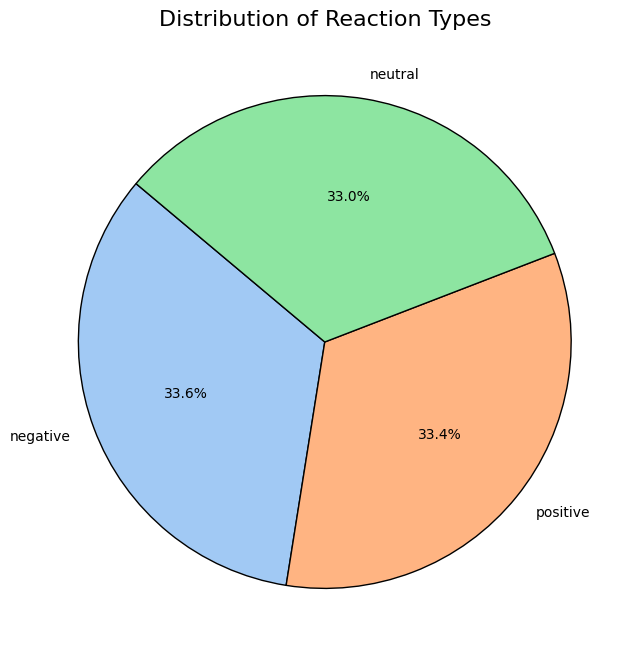

In [14]:
reaction_counts = df_data['reaction_type'].value_counts()
colors = sns.color_palette("pastel")
plt.figure(figsize=(8, 8))
plt.pie(reaction_counts, labels=reaction_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title("Distribution of Reaction Types", fontsize=16)
plt.show()

In [15]:
def text_to_word_list(text):
    text = text.split()
    return text

def replace_strings(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\u00C0-\u017F"          #latin
                           u"\u2000-\u206F"          #generalPunctuations

                           "]+", flags=re.UNICODE)
    english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
    #latin_pattern=re.compile('[A-Za-z\u00C0-\u00D6\u00D8-\u00f6\u00f8-\u00ff\s]*',)

    text=emoji_pattern.sub(r'', text)
    text=english_pattern.sub(r'', text)

    return text

def remove_punctuations(my_str):
    # define punctuation
    punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰🤣⚽️✌�￰৷￰'''

    no_punct = ""
    for char in my_str:
        if char not in punctuations:
            no_punct = no_punct + char

    # display the unpunctuated string
    return no_punct

def joining(text):
    out=' '.join(text)
    return out

def preprocessing(text):
    out=remove_punctuations(replace_strings(text))
    return out

In [16]:
import re

df_data['comments'] = df_data.comments.apply(lambda x: preprocessing(str(x)))

In [17]:
df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,negative
1,এটার সেকেন্ড পার্ট চাই দিদি আজ শুধু রাবণের রোস...,negative
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,negative
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,negative
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,positive
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,negative
21171,অসাধারন লেগেছে ভালো লেগেছে,negative
21172,স্যতি অসাধারণ,negative
21173,তে এই ফিল্ম টি দেখছিলাম অসাধারণ একটি মুভি,negative


In [18]:
df_data["reaction_type"] = df_data["reaction_type"].replace({"negative": "0", "positive": "1", "neutral": "2"})

In [19]:
df_data

,comments,reaction_type
0,আগের জীবনে অনেক পূণ্য করেছিলাম বলে এই জীবনে আদ...,0
1,এটার সেকেন্ড পার্ট চাই দিদি আজ শুধু রাবণের রোস...,0
2,রাবণের ব্যাটা কিন্তু যথেষ্ঠ করে,0
3,বিভীষণ আবার আমার লাল কালো শাড়িটা ঝেঁপে দিয়েছ...,0
4,সত্যি দিদি হাসতে হাসতে পেট ব্যথা হয়ে গেলো আর ক...,1
...,...,...
21170,আপনি যদি মুসলিম হউন প্লিজ সালাম দিয়ে ভিডিওটা শ...,0
21171,অসাধারন লেগেছে ভালো লেগেছে,0
21172,স্যতি অসাধারণ,0
21173,তে এই ফিল্ম টি দেখছিলাম অসাধারণ একটি মুভি,0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(df_data['comments'], df_data['reaction_type'], test_size=0.2, random_state=42)

## CNN - LSTM

Epoch [1/25], Loss: 1.0681
Epoch [2/25], Loss: 0.9789
Epoch [3/25], Loss: 0.8701
Epoch [4/25], Loss: 0.7506
Epoch [5/25], Loss: 0.6286
Epoch [6/25], Loss: 0.5248
Epoch [7/25], Loss: 0.4542
Epoch [8/25], Loss: 0.3890
Epoch [9/25], Loss: 0.3430
Epoch [10/25], Loss: 0.3159
Epoch [11/25], Loss: 0.2828
Epoch [12/25], Loss: 0.2618
Epoch [13/25], Loss: 0.2405
Epoch [14/25], Loss: 0.2324
Epoch [15/25], Loss: 0.2199
Epoch [16/25], Loss: 0.2171
Epoch [17/25], Loss: 0.1969
Epoch [18/25], Loss: 0.1969
Epoch [19/25], Loss: 0.1820
Epoch [20/25], Loss: 0.1887
Epoch [21/25], Loss: 0.1730
Epoch [22/25], Loss: 0.1786
Epoch [23/25], Loss: 0.1706
Epoch [24/25], Loss: 0.1590
Epoch [25/25], Loss: 0.1537


    Testing Accuracy:               57.19%          

       Precision :                  57.39%          

         Recall :                   57.19%          

        F1 Score :                  57.13%          




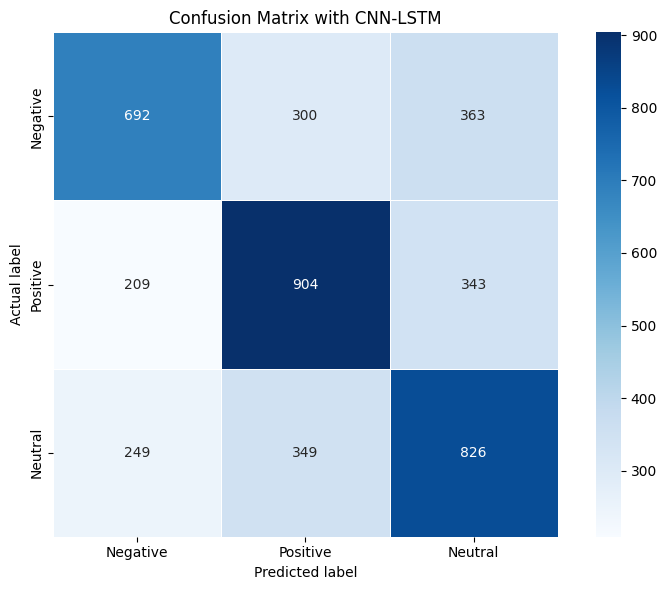


              Classification Report:              

    Class          Precision        Recall         F1-Score    
    Negative              60.17 %      51.07 %      55.25 %
    Positive              58.21 %      62.09 %      60.09 %
    Neutral               53.92 %      58.01 %      55.89 %
    accuracy              57.19 %      57.19 %      57.19 %
   macro avg              57.43 %      57.05 %      57.07 %
  weighted avg            57.39 %      57.19 %      57.13 %



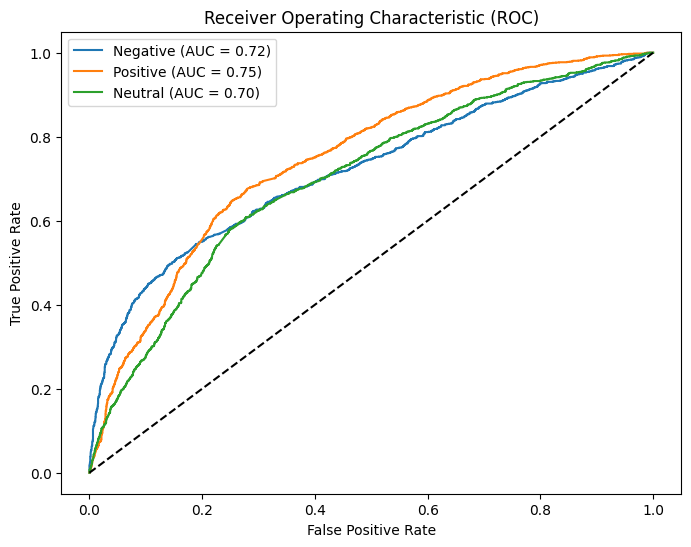

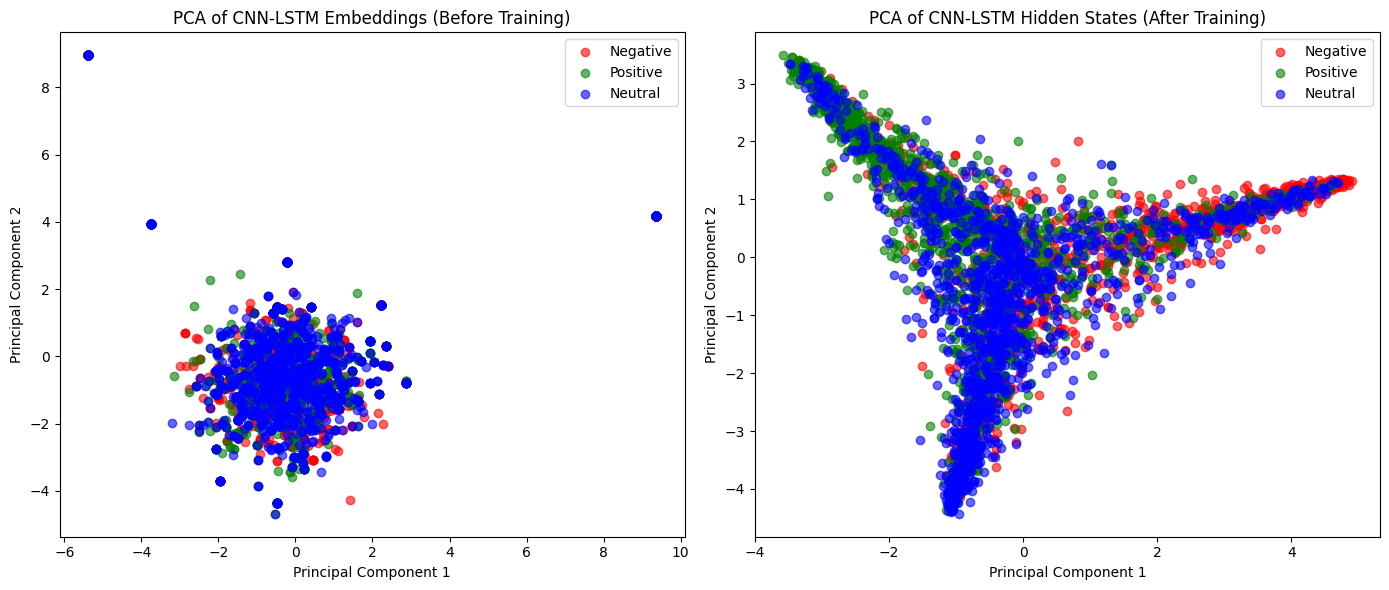

In [21]:

# Tokenization and Padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Label Encoding
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train)
y_test_bin = lb.transform(y_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_train_tensor = torch.tensor(np.argmax(y_train_bin, axis=1), dtype=torch.long)
y_test_tensor = torch.tensor(np.argmax(y_test_bin, axis=1), dtype=torch.long)

# 2. Define CNN-LSTM Model
class CNNLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(CNNLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv1d(embedding_dim, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.lstm = nn.LSTM(128, hidden_dim, num_layers=2, dropout=0.5, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.permute(0, 2, 1)
        _, (hn, _) = self.lstm(x)
        x = self.dropout(hn[-1])
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Model parameters
vocab_size = 10000
embedding_dim = 128
hidden_dim = 64
output_dim = len(lb.classes_)

# Initialize model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNLSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training
initial_batch_size = 32
memory_target = 0.8 * torch.cuda.get_device_properties(0).total_memory  # 80% of total memory

# Create DataLoader with dynamic batch size
def create_dataloader(X, y, batch_size):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Function to determine the maximum batch size within memory limit
def optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size):
    batch_size = initial_batch_size
    while True:
        train_loader = create_dataloader(X_train_tensor, y_train_tensor, batch_size)
        try:
            # Run a single forward pass to check memory usage
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()  # No need to perform optimizer step here
                torch.cuda.empty_cache()  # Clear cache
            break
        except RuntimeError as e:
            if 'CUDA out of memory' in str(e):
                batch_size = max(1, batch_size // 2)  # Reduce batch size if OOM occurs
                print(f"Reducing batch size to: {batch_size}")
            else:
                raise e
    return batch_size

# Adjusted model, criterion, and optimizer initialization
model = CNNLSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optimize batch size and create DataLoader
optimized_batch_size = optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size)
train_loader = create_dataloader(X_train_tensor, y_train_tensor, optimized_batch_size)

# 3. Training with optimized batch size
epochs = 25
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

# 4. Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor.to(device))
    y_pred = torch.argmax(outputs, axis=1).cpu().numpy()
    y_test_single = y_test_tensor.numpy()

# Metrics
accuracy = accuracy_score(y_test_single, y_pred) * 100
precision = precision_score(y_test_single, y_pred, average='weighted') * 100
recall = recall_score(y_test_single, y_pred, average='weighted') * 100
fscore = f1_score(y_test_single, y_pred, average='weighted') * 100

# Print with larger font-like effect and padding, all metrics in percentage
print("\n" + "="*50)
print("\n" + "Testing Accuracy:".center(25, " "), f"{accuracy:.2f}%".center(25, " "), "\n")
print("Precision :".center(25, " "), f"{precision:.2f}%".center(25, " "), "\n")
print("Recall :".center(25, " "), f"{recall:.2f}%".center(25, " "), "\n")
print("F1 Score :".center(25, " "), f"{fscore:.2f}%".center(25, " "), "\n")
print("="*50 + "\n")

# Confusion Matrix
cm = confusion_matrix(y_test_single, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=['Negative', 'Positive', 'Neutral'], columns=['Negative', 'Positive', 'Neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with CNN-LSTM')
plt.tight_layout()
plt.show()

# Generate classification report
report = pd.DataFrame(classification_report(y_test_single, y_pred, labels=[0, 1, 2], output_dict=True)).transpose()
report = report.rename(index={'0': 'Negative', '1': 'Positive', '2': 'Neutral'})
report[['precision', 'recall', 'f1-score']] = report[['precision', 'recall', 'f1-score']].apply(lambda x: round(x * 100, 2))

# Print classification report with larger font-like effect and padding
print("\n" + "="*70)
print("Classification Report:".center(50, " "))
print("="*50)
print("\n" + " Class   ".center(15, " "), " Precision  ".center(15, " "), " Recall  ".center(15, " "), " F1-Score  ".center(15, " "))
print("="*50)

for index, row in report.iterrows():
    print(f"{index.center(15, ' ')} {row['precision']:>15} % {row['recall']:>10} % {row['f1-score']:>10} %")

print("="*70 + "\n")

# ROC Curve
n_classes = len(lb.classes_)
y_test_bin_binarized = label_binarize(y_test_single, classes=[0, 1, 2])
y_pred_prob = torch.softmax(outputs, dim=1).cpu().numpy()
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{["Negative", "Positive", "Neutral"][i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='best')
plt.show()

# 5. PCA Visualization (Before and After Training)
def get_pca_embeddings(embeddings):
    pca = PCA(n_components=2)
    return pca.fit_transform(embeddings)

def plot_pca_side_by_side(before_embeddings, after_embeddings, labels):
    before_pca = get_pca_embeddings(before_embeddings)
    after_pca = get_pca_embeddings(after_embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    label_names = ['Negative', 'Positive', 'Neutral']
    colors = ['red', 'green', 'blue']
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[0].scatter(before_pca[indices, 0], before_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[0].set_title('PCA of CNN-LSTM Embeddings (Before Training)')
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[1].scatter(after_pca[indices, 0], after_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[1].set_title('PCA of CNN-LSTM Hidden States (After Training)')
    for ax in axes:
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend()
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    initial_hidden_states = model.embedding(X_test_tensor.to(device))[:, -1, :].cpu().numpy()

model.eval()
with torch.no_grad():
    final_hidden_states = model.embedding(X_test_tensor.to(device))
    final_hidden_states = model.pool(torch.relu(model.conv1(final_hidden_states.permute(0, 2, 1)))).permute(0, 2, 1)
    _, (hn, _) = model.lstm(final_hidden_states)
    final_hidden_states = hn[-1].cpu().numpy()

plot_pca_side_by_side(initial_hidden_states, final_hidden_states, y_test_single)

In [22]:
import torch
print(torch.cuda.is_available())


True


## CNN - Bi LSTM

Epoch [1/30], Loss: 1.0573
Epoch [2/30], Loss: 0.9566
Epoch [3/30], Loss: 0.8388
Epoch [4/30], Loss: 0.7132
Epoch [5/30], Loss: 0.5985
Epoch [6/30], Loss: 0.4945
Epoch [7/30], Loss: 0.4118
Epoch [8/30], Loss: 0.3574
Epoch [9/30], Loss: 0.3143
Epoch [10/30], Loss: 0.2863
Epoch [11/30], Loss: 0.2634
Epoch [12/30], Loss: 0.2380
Epoch [13/30], Loss: 0.2193
Epoch [14/30], Loss: 0.2245
Epoch [15/30], Loss: 0.2020
Epoch [16/30], Loss: 0.1993
Epoch [17/30], Loss: 0.1881
Epoch [18/30], Loss: 0.1850
Epoch [19/30], Loss: 0.1807
Epoch [20/30], Loss: 0.1669
Epoch [21/30], Loss: 0.1588
Epoch [22/30], Loss: 0.1611
Epoch [23/30], Loss: 0.1470
Epoch [24/30], Loss: 0.1635
Epoch [25/30], Loss: 0.1651
Epoch [26/30], Loss: 0.1524
Epoch [27/30], Loss: 0.1384
Epoch [28/30], Loss: 0.1355
Epoch [29/30], Loss: 0.1361
Epoch [30/30], Loss: 0.1404


    Testing Accuracy:               57.05%          

       Precision :                  57.33%          

         Recall :                   57.05%          

     

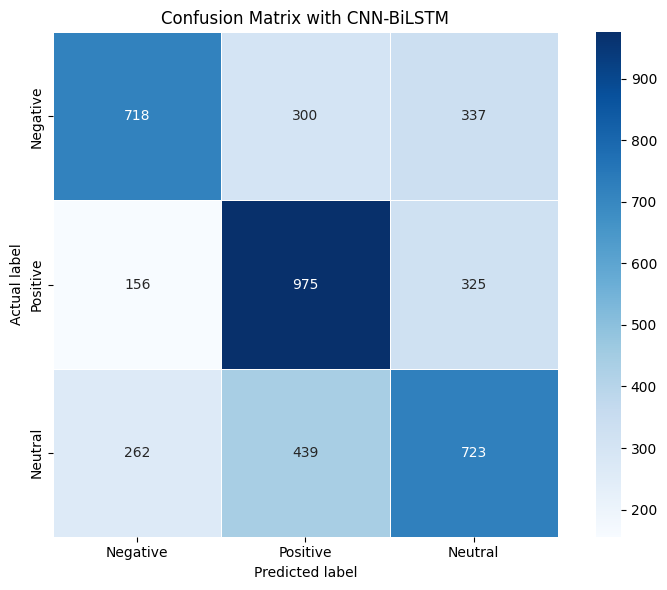


              Classification Report:              

    Class          Precision        Recall         F1-Score    
    Negative               63.2 %      52.99 %      57.65 %
    Positive              56.88 %      66.96 %      61.51 %
    Neutral                52.2 %      50.77 %      51.48 %
    accuracy              57.05 %      57.05 %      57.05 %
   macro avg              57.43 %      56.91 %      56.88 %
  weighted avg            57.33 %      57.05 %       56.9 %



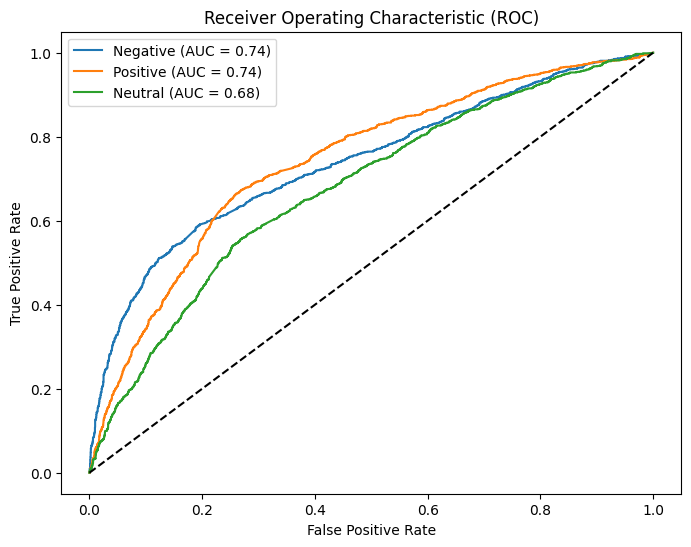

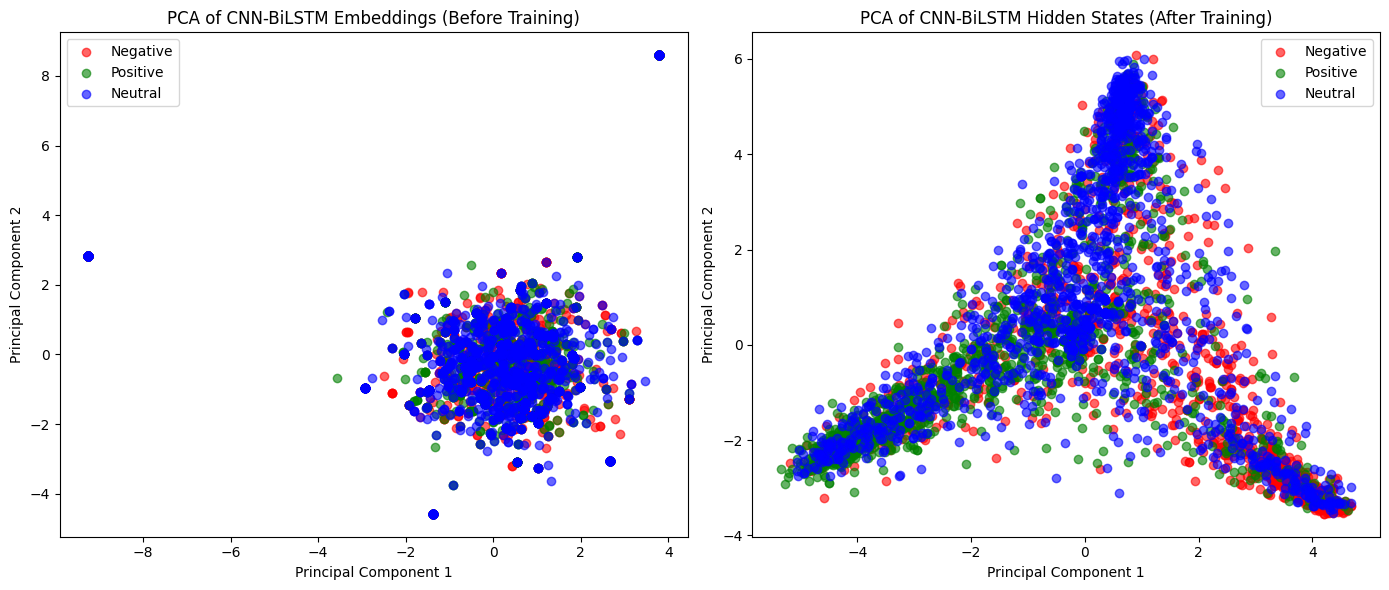

In [23]:

X_train, X_test, y_train, y_test = train_test_split(df_data['comments'], df_data['reaction_type'], test_size=0.2, random_state=42)

# Tokenization and Padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Label Encoding
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train)
y_test_bin = lb.transform(y_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_train_tensor = torch.tensor(np.argmax(y_train_bin, axis=1), dtype=torch.long)
y_test_tensor = torch.tensor(np.argmax(y_test_bin, axis=1), dtype=torch.long)

# Create DataLoader with batch size
batch_size = 64
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# 2. Define CNN-BiLSTM Model
class CNNBiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(CNNBiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv1d(embedding_dim, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.bilstm = nn.LSTM(128, hidden_dim, num_layers=2, dropout=0.5, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)  # hidden_dim * 2 for bidirectional
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.permute(0, 2, 1)
        _, (hn, _) = self.bilstm(x)
        x = self.dropout(torch.cat((hn[-2], hn[-1]), dim=1))  # Concatenate the hidden states from both directions
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Model parameters
vocab_size = 10000
embedding_dim = 128
hidden_dim = 64
output_dim = len(lb.classes_)

# Initialize model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNBiLSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training
initial_batch_size = 32
memory_target = 0.8 * torch.cuda.get_device_properties(0).total_memory  # 80% of total memory

# Create DataLoader with dynamic batch size
def create_dataloader(X, y, batch_size):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Function to determine the maximum batch size within memory limit
def optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size):
    batch_size = initial_batch_size
    while True:
        train_loader = create_dataloader(X_train_tensor, y_train_tensor, batch_size)
        try:
            # Run a single forward pass to check memory usage
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()  # No need to perform optimizer step here
                torch.cuda.empty_cache()  # Clear cache
            break
        except RuntimeError as e:
            if 'CUDA out of memory' in str(e):
                batch_size = max(1, batch_size // 2)  # Reduce batch size if OOM occurs
                print(f"Reducing batch size to: {batch_size}")
            else:
                raise e
    return batch_size

# Adjusted model, criterion, and optimizer initialization
model = CNNBiLSTMModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optimize batch size and create DataLoader
optimized_batch_size = optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size)
train_loader = create_dataloader(X_train_tensor, y_train_tensor, optimized_batch_size)

# 3. Training with optimized batch size
epochs = 30
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

# 4. Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor.to(device))
    y_pred = torch.argmax(outputs, axis=1).cpu().numpy()
    y_test_single = y_test_tensor.numpy()

# Metrics
accuracy = accuracy_score(y_test_single, y_pred) * 100
precision = precision_score(y_test_single, y_pred, average='weighted') * 100
recall = recall_score(y_test_single, y_pred, average='weighted') * 100
fscore = f1_score(y_test_single, y_pred, average='weighted') * 100

# Print with larger font-like effect and padding, all metrics in percentage
print("\n" + "="*50)
print("\n" + "Testing Accuracy:".center(25, " "), f"{accuracy:.2f}%".center(25, " "), "\n")
print("Precision :".center(25, " "), f"{precision:.2f}%".center(25, " "), "\n")
print("Recall :".center(25, " "), f"{recall:.2f}%".center(25, " "), "\n")
print("F1 Score :".center(25, " "), f"{fscore:.2f}%".center(25, " "), "\n")
print("="*50 + "\n")

# Confusion Matrix
cm = confusion_matrix(y_test_single, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=['Negative', 'Positive', 'Neutral'], columns=['Negative', 'Positive', 'Neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with CNN-BiLSTM')
plt.tight_layout()
plt.show()

# Generate classification report
report = pd.DataFrame(classification_report(y_test_single, y_pred, labels=[0, 1, 2], output_dict=True)).transpose()
report = report.rename(index={'0': 'Negative', '1': 'Positive', '2': 'Neutral'})
report[['precision', 'recall', 'f1-score']] = report[['precision', 'recall', 'f1-score']].apply(lambda x: round(x * 100, 2))

# Print classification report with larger font-like effect and padding
print("\n" + "="*70)
print("Classification Report:".center(50, " "))
print("="*50)
print("\n" + " Class   ".center(15, " "), " Precision  ".center(15, " "), " Recall  ".center(15, " "), " F1-Score  ".center(15, " "))
print("="*50)

for index, row in report.iterrows():
    print(f"{index.center(15, ' ')} {row['precision']:>15} % {row['recall']:>10} % {row['f1-score']:>10} %")

print("="*70 + "\n")

# ROC Curve
n_classes = len(lb.classes_)
y_test_bin_binarized = label_binarize(y_test_single, classes=[0, 1, 2])
y_pred_prob = torch.softmax(outputs, dim=1).cpu().numpy()
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{["Negative", "Positive", "Neutral"][i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='best')
plt.show()

# 5. PCA Visualization (Before and After Training)
def get_pca_embeddings(embeddings):
    pca = PCA(n_components=2)
    return pca.fit_transform(embeddings)

def plot_pca_side_by_side(before_embeddings, after_embeddings, labels):
    before_pca = get_pca_embeddings(before_embeddings)
    after_pca = get_pca_embeddings(after_embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    label_names = ['Negative', 'Positive', 'Neutral']
    colors = ['red', 'green', 'blue']
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[0].scatter(before_pca[indices, 0], before_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[0].set_title('PCA of CNN-BiLSTM Embeddings (Before Training)')
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[1].scatter(after_pca[indices, 0], after_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[1].set_title('PCA of CNN-BiLSTM Hidden States (After Training)')
    for ax in axes:
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend()
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    initial_hidden_states = model.embedding(X_test_tensor.to(device))[:, -1, :].cpu().numpy()

model.eval()
with torch.no_grad():
    final_hidden_states = model.embedding(X_test_tensor.to(device))
    final_hidden_states = model.pool(torch.relu(model.conv1(final_hidden_states.permute(0, 2, 1)))).permute(0, 2, 1)
    _, (hn, _) = model.bilstm(final_hidden_states)
    final_hidden_states = torch.cat((hn[-2], hn[-1]), dim=1).cpu().numpy()

plot_pca_side_by_side(initial_hidden_states, final_hidden_states, y_test_single)

## CNN- GRU

Epoch [1/40], Loss: 1.0587
Epoch [2/40], Loss: 0.9520
Epoch [3/40], Loss: 0.8278
Epoch [4/40], Loss: 0.6955
Epoch [5/40], Loss: 0.5646
Epoch [6/40], Loss: 0.4711
Epoch [7/40], Loss: 0.3964
Epoch [8/40], Loss: 0.3411
Epoch [9/40], Loss: 0.3058
Epoch [10/40], Loss: 0.2836
Epoch [11/40], Loss: 0.2533
Epoch [12/40], Loss: 0.2444
Epoch [13/40], Loss: 0.2346
Epoch [14/40], Loss: 0.2151
Epoch [15/40], Loss: 0.2138
Epoch [16/40], Loss: 0.1961
Epoch [17/40], Loss: 0.1921
Epoch [18/40], Loss: 0.1904
Epoch [19/40], Loss: 0.1846
Epoch [20/40], Loss: 0.1827
Epoch [21/40], Loss: 0.1752
Epoch [22/40], Loss: 0.1746
Epoch [23/40], Loss: 0.1739
Epoch [24/40], Loss: 0.1607
Epoch [25/40], Loss: 0.1581
Epoch [26/40], Loss: 0.1537
Epoch [27/40], Loss: 0.1539
Epoch [28/40], Loss: 0.1565
Epoch [29/40], Loss: 0.1451
Epoch [30/40], Loss: 0.1443
Epoch [31/40], Loss: 0.1518
Epoch [32/40], Loss: 0.1484
Epoch [33/40], Loss: 0.1486
Epoch [34/40], Loss: 0.1411
Epoch [35/40], Loss: 0.1367
Epoch [36/40], Loss: 0.1313
E

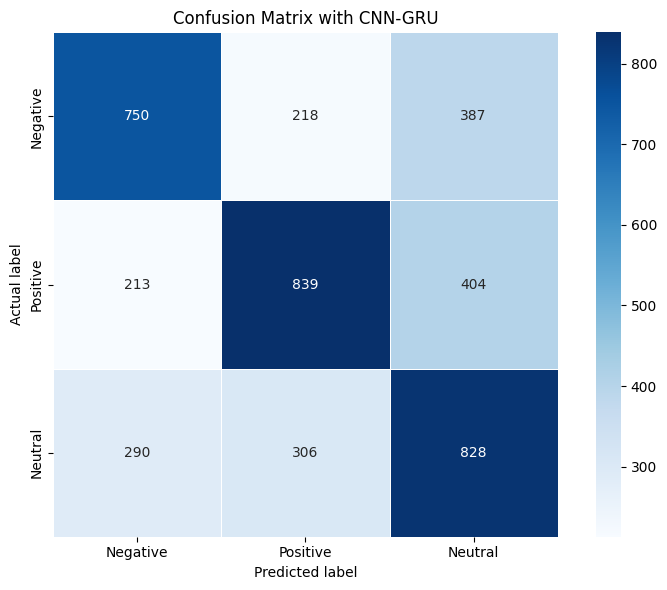


              Classification Report:              

    Class          Precision        Recall         F1-Score    
    Negative              59.86 %      55.35 %      57.52 %
    Positive              61.56 %      57.62 %      59.52 %
    Neutral               51.14 %      58.15 %      54.42 %
    accuracy              57.07 %      57.07 %      57.07 %
   macro avg              57.52 %      57.04 %      57.15 %
  weighted avg            57.51 %      57.07 %      57.17 %



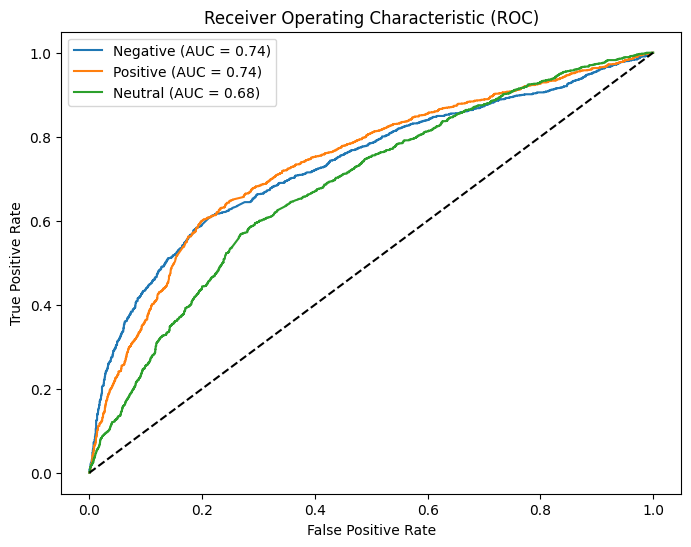

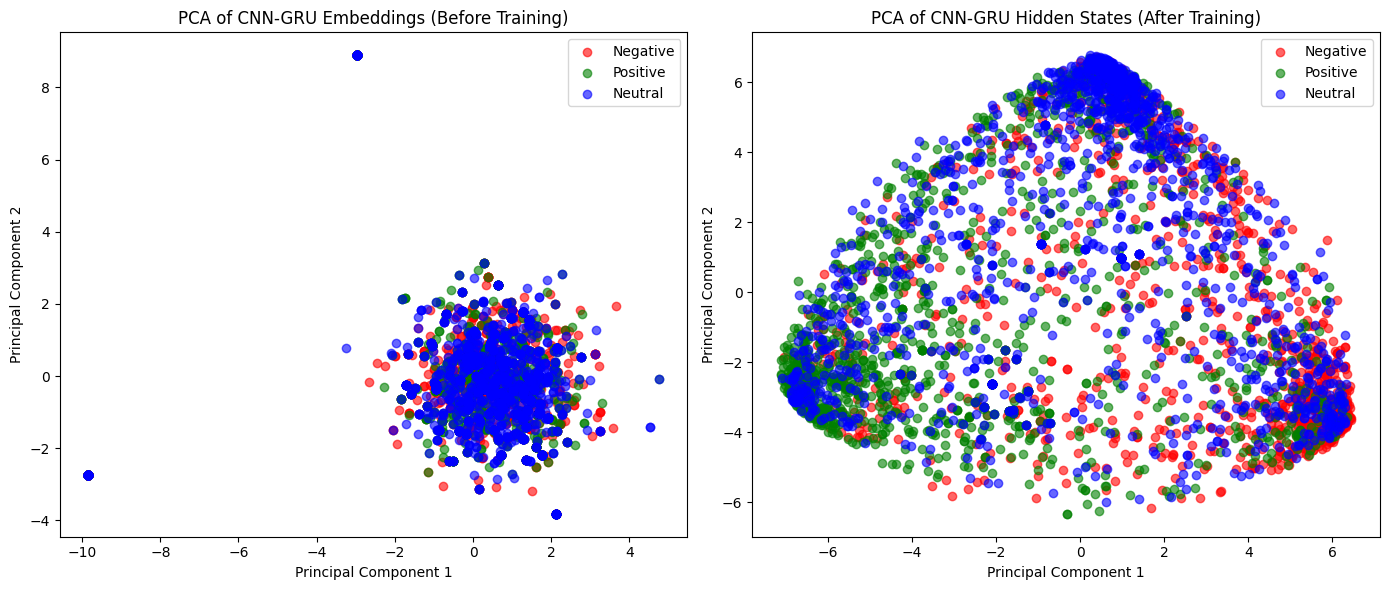

In [24]:

# Tokenization and Padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Label Encoding
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train)
y_test_bin = lb.transform(y_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_train_tensor = torch.tensor(np.argmax(y_train_bin, axis=1), dtype=torch.long)
y_test_tensor = torch.tensor(np.argmax(y_test_bin, axis=1), dtype=torch.long)

# Create DataLoader with batch size
batch_size = 64
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# 2. Define CNN-GRU Model
class CNNGRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(CNNGRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv1d(embedding_dim, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.gru = nn.GRU(128, hidden_dim, num_layers=2, dropout=0.5, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.permute(0, 2, 1)
        _, hn = self.gru(x)
        x = self.dropout(hn[-1])
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Model parameters
vocab_size = 10000
embedding_dim = 128
hidden_dim = 64
output_dim = len(lb.classes_)

# Initialize model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNGRUModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training
initial_batch_size = 32
memory_target = 0.8 * torch.cuda.get_device_properties(0).total_memory  # 80% of total memory

# Create DataLoader with dynamic batch size
def create_dataloader(X, y, batch_size):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Function to determine the maximum batch size within memory limit
def optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size):
    batch_size = initial_batch_size
    while True:
        train_loader = create_dataloader(X_train_tensor, y_train_tensor, batch_size)
        try:
            # Run a single forward pass to check memory usage
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()  # No need to perform optimizer step here
                torch.cuda.empty_cache()  # Clear cache
            break
        except RuntimeError as e:
            if 'CUDA out of memory' in str(e):
                batch_size = max(1, batch_size // 2)  # Reduce batch size if OOM occurs
                print(f"Reducing batch size to: {batch_size}")
            else:
                raise e
    return batch_size

# Adjusted model, criterion, and optimizer initialization
model = CNNGRUModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optimize batch size and create DataLoader
optimized_batch_size = optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size)
train_loader = create_dataloader(X_train_tensor, y_train_tensor, optimized_batch_size)

# 3. Training with optimized batch size
epochs = 40
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

# 4. Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor.to(device))
    y_pred = torch.argmax(outputs, axis=1).cpu().numpy()
    y_test_single = y_test_tensor.numpy()

# Metrics
accuracy = accuracy_score(y_test_single, y_pred) * 100
precision = precision_score(y_test_single, y_pred, average='weighted') * 100
recall = recall_score(y_test_single, y_pred, average='weighted') * 100
fscore = f1_score(y_test_single, y_pred, average='weighted') * 100

# Print with larger font-like effect and padding, all metrics in percentage
print("\n" + "="*50)
print("\n" + "Testing Accuracy:".center(25, " "), f"{accuracy:.2f}%".center(25, " "), "\n")
print("Precision :".center(25, " "), f"{precision:.2f}%".center(25, " "), "\n")
print("Recall :".center(25, " "), f"{recall:.2f}%".center(25, " "), "\n")
print("F1 Score :".center(25, " "), f"{fscore:.2f}%".center(25, " "), "\n")
print("="*50 + "\n")

# Confusion Matrix
cm = confusion_matrix(y_test_single, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=['Negative', 'Positive', 'Neutral'], columns=['Negative', 'Positive', 'Neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with CNN-GRU')
plt.tight_layout()
plt.show()

# Generate classification report
report = pd.DataFrame(classification_report(y_test_single, y_pred, labels=[0, 1, 2], output_dict=True)).transpose()
report = report.rename(index={'0': 'Negative', '1': 'Positive', '2': 'Neutral'})
report[['precision', 'recall', 'f1-score']] = report[['precision', 'recall', 'f1-score']].apply(lambda x: round(x * 100, 2))

# Print classification report with larger font-like effect and padding
print("\n" + "="*70)
print("Classification Report:".center(50, " "))
print("="*50)
print("\n" + " Class   ".center(15, " "), " Precision  ".center(15, " "), " Recall  ".center(15, " "), " F1-Score  ".center(15, " "))
print("="*50)

for index, row in report.iterrows():
    print(f"{index.center(15, ' ')} {row['precision']:>15} % {row['recall']:>10} % {row['f1-score']:>10} %")

print("="*70 + "\n")

# ROC Curve
n_classes = len(lb.classes_)
y_test_bin_binarized = label_binarize(y_test_single, classes=[0, 1, 2])
y_pred_prob = torch.softmax(outputs, dim=1).cpu().numpy()
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{["Negative", "Positive", "Neutral"][i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='best')
plt.show()

# 5. PCA Visualization (Before and After Training)
def get_pca_embeddings(embeddings):
    pca = PCA(n_components=2)
    return pca.fit_transform(embeddings)

def plot_pca_side_by_side(before_embeddings, after_embeddings, labels):
    before_pca = get_pca_embeddings(before_embeddings)
    after_pca = get_pca_embeddings(after_embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    label_names = ['Negative', 'Positive', 'Neutral']
    colors = ['red', 'green', 'blue']
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[0].scatter(before_pca[indices, 0], before_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[0].set_title('PCA of CNN-GRU Embeddings (Before Training)')
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[1].scatter(after_pca[indices, 0], after_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[1].set_title('PCA of CNN-GRU Hidden States (After Training)')
    for ax in axes:
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend()
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    initial_hidden_states = model.embedding(X_test_tensor.to(device))[:, -1, :].cpu().numpy()

model.eval()
with torch.no_grad():
    final_hidden_states = model.embedding(X_test_tensor.to(device))
    final_hidden_states = model.pool(torch.relu(model.conv1(final_hidden_states.permute(0, 2, 1)))).permute(0, 2, 1)
    _, hn = model.gru(final_hidden_states)
    final_hidden_states = hn[-1].cpu().numpy()

plot_pca_side_by_side(initial_hidden_states, final_hidden_states, y_test_single)

## CNN-BiGRU

Epoch [1/50], Loss: 1.0635
Epoch [2/50], Loss: 0.9622
Epoch [3/50], Loss: 0.8388
Epoch [4/50], Loss: 0.6964
Epoch [5/50], Loss: 0.5589
Epoch [6/50], Loss: 0.4520
Epoch [7/50], Loss: 0.3747
Epoch [8/50], Loss: 0.3191
Epoch [9/50], Loss: 0.2773
Epoch [10/50], Loss: 0.2569
Epoch [11/50], Loss: 0.2255
Epoch [12/50], Loss: 0.2146
Epoch [13/50], Loss: 0.1999
Epoch [14/50], Loss: 0.1922
Epoch [15/50], Loss: 0.1828
Epoch [16/50], Loss: 0.1742
Epoch [17/50], Loss: 0.1698
Epoch [18/50], Loss: 0.1632
Epoch [19/50], Loss: 0.1571
Epoch [20/50], Loss: 0.1544
Epoch [21/50], Loss: 0.1447
Epoch [22/50], Loss: 0.1421
Epoch [23/50], Loss: 0.1381
Epoch [24/50], Loss: 0.1397
Epoch [25/50], Loss: 0.1336
Epoch [26/50], Loss: 0.1297
Epoch [27/50], Loss: 0.1429
Epoch [28/50], Loss: 0.1317
Epoch [29/50], Loss: 0.1252
Epoch [30/50], Loss: 0.1214
Epoch [31/50], Loss: 0.1220
Epoch [32/50], Loss: 0.1222
Epoch [33/50], Loss: 0.1273
Epoch [34/50], Loss: 0.1292
Epoch [35/50], Loss: 0.1219
Epoch [36/50], Loss: 0.1196
E

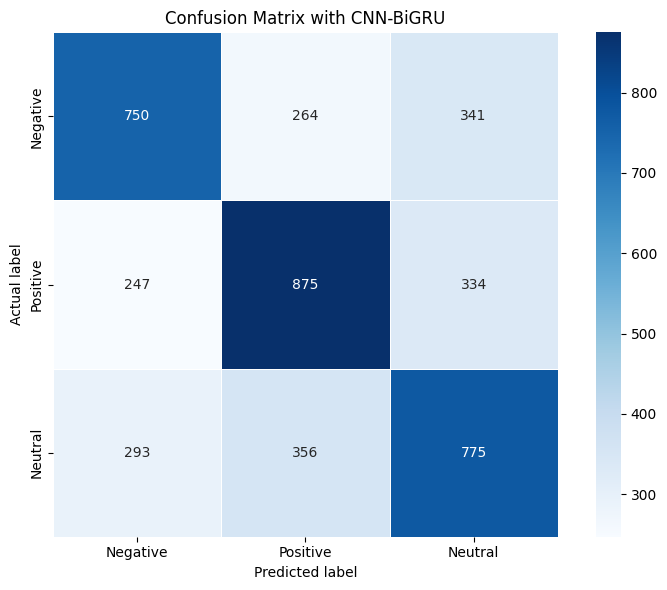


              Classification Report:              

    Class          Precision        Recall         F1-Score    
    Negative              58.14 %      55.35 %      56.71 %
    Positive              58.53 %       60.1 %       59.3 %
    Neutral               53.45 %      54.42 %      53.93 %
    accuracy              56.67 %      56.67 %      56.67 %
   macro avg              56.71 %      56.62 %      56.65 %
  weighted avg             56.7 %      56.67 %      56.67 %



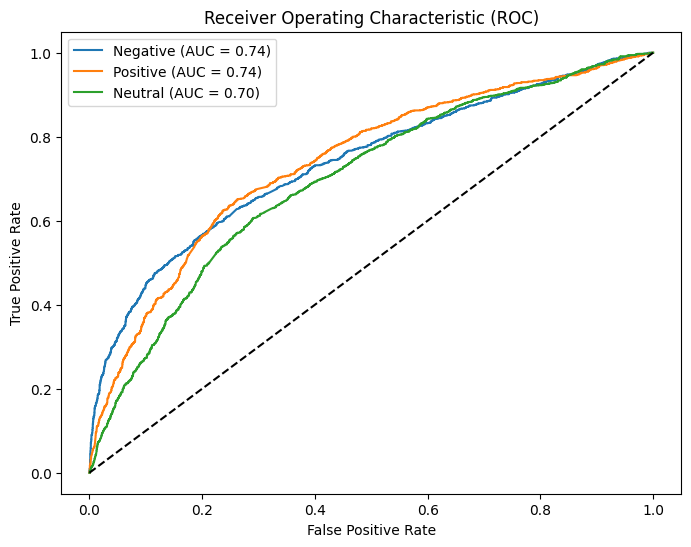

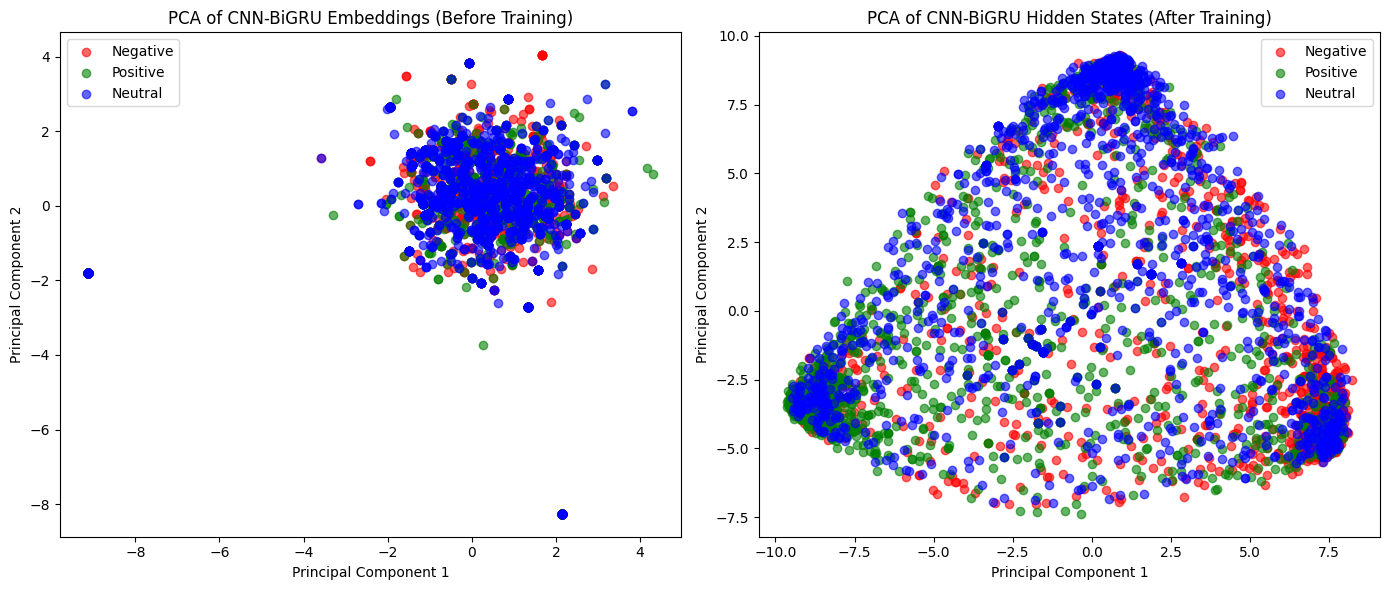

In [25]:


# Tokenization and Padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# Label Encoding
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train)
y_test_bin = lb.transform(y_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)
y_train_tensor = torch.tensor(np.argmax(y_train_bin, axis=1), dtype=torch.long)
y_test_tensor = torch.tensor(np.argmax(y_test_bin, axis=1), dtype=torch.long)

# Create DataLoader with batch size
batch_size = 64
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# 2. Define CNN-BiGRU Model
class CNNBiGRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(CNNBiGRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv1d(embedding_dim, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.bigru = nn.GRU(128, hidden_dim, num_layers=2, dropout=0.5, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)  # hidden_dim * 2 for bidirectional
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.permute(0, 2, 1)
        _, hn = self.bigru(x)
        x = self.dropout(torch.cat((hn[-2], hn[-1]), dim=1))  # Concatenate the hidden states from both directions
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Model parameters
vocab_size = 10000
embedding_dim = 128
hidden_dim = 64
output_dim = len(lb.classes_)

# Initialize model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNBiGRUModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training
initial_batch_size = 32
memory_target = 0.8 * torch.cuda.get_device_properties(0).total_memory  # 80% of total memory

# Create DataLoader with dynamic batch size
def create_dataloader(X, y, batch_size):
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Function to determine the maximum batch size within memory limit
def optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size):
    batch_size = initial_batch_size
    while True:
        train_loader = create_dataloader(X_train_tensor, y_train_tensor, batch_size)
        try:
            # Run a single forward pass to check memory usage
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()  # No need to perform optimizer step here
                torch.cuda.empty_cache()  # Clear cache
            break
        except RuntimeError as e:
            if 'CUDA out of memory' in str(e):
                batch_size = max(1, batch_size // 2)  # Reduce batch size if OOM occurs
                print(f"Reducing batch size to: {batch_size}")
            else:
                raise e
    return batch_size

# Adjusted model, criterion, and optimizer initialization
model = CNNBiGRUModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optimize batch size and create DataLoader
optimized_batch_size = optimize_batch_size(model, optimizer, X_train_tensor, y_train_tensor, initial_batch_size)
train_loader = create_dataloader(X_train_tensor, y_train_tensor, optimized_batch_size)

# 3. Training with optimized batch size
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")

# 4. Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor.to(device))
    y_pred = torch.argmax(outputs, axis=1).cpu().numpy()
    y_test_single = y_test_tensor.numpy()

# Metrics
accuracy = accuracy_score(y_test_single, y_pred) * 100
precision = precision_score(y_test_single, y_pred, average='weighted') * 100
recall = recall_score(y_test_single, y_pred, average='weighted') * 100
fscore = f1_score(y_test_single, y_pred, average='weighted') * 100

# Print with larger font-like effect and padding, all metrics in percentage
print("\n" + "="*50)
print("\n" + "Testing Accuracy:".center(25, " "), f"{accuracy:.2f}%".center(25, " "), "\n")
print("Precision :".center(25, " "), f"{precision:.2f}%".center(25, " "), "\n")
print("Recall :".center(25, " "), f"{recall:.2f}%".center(25, " "), "\n")
print("F1 Score :".center(25, " "), f"{fscore:.2f}%".center(25, " "), "\n")
print("="*50 + "\n")

# Confusion Matrix
cm = confusion_matrix(y_test_single, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=['Negative', 'Positive', 'Neutral'], columns=['Negative', 'Positive', 'Neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', linewidths=.5, square=True, cmap='Blues')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix with CNN-BiGRU')
plt.tight_layout()
plt.show()

# Generate classification report
report = pd.DataFrame(classification_report(y_test_single, y_pred, labels=[0, 1, 2], output_dict=True)).transpose()
report = report.rename(index={'0': 'Negative', '1': 'Positive', '2': 'Neutral'})
report[['precision', 'recall', 'f1-score']] = report[['precision', 'recall', 'f1-score']].apply(lambda x: round(x * 100, 2))

# Print classification report with larger font-like effect and padding
print("\n" + "="*70)
print("Classification Report:".center(50, " "))
print("="*50)
print("\n" + " Class   ".center(15, " "), " Precision  ".center(15, " "), " Recall  ".center(15, " "), " F1-Score  ".center(15, " "))
print("="*50)

for index, row in report.iterrows():
    print(f"{index.center(15, ' ')} {row['precision']:>15} % {row['recall']:>10} % {row['f1-score']:>10} %")

print("="*70 + "\n")

# ROC Curve
n_classes = len(lb.classes_)
y_test_bin_binarized = label_binarize(y_test_single, classes=[0, 1, 2])
y_pred_prob = torch.softmax(outputs, dim=1).cpu().numpy()
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{["Negative", "Positive", "Neutral"][i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='best')
plt.show()

# 5. PCA Visualization (Before and After Training)
def get_pca_embeddings(embeddings):
    pca = PCA(n_components=2)
    return pca.fit_transform(embeddings)

def plot_pca_side_by_side(before_embeddings, after_embeddings, labels):
    before_pca = get_pca_embeddings(before_embeddings)
    after_pca = get_pca_embeddings(after_embeddings)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    label_names = ['Negative', 'Positive', 'Neutral']
    colors = ['red', 'green', 'blue']
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[0].scatter(before_pca[indices, 0], before_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[0].set_title('PCA of CNN-BiGRU Embeddings (Before Training)')
    
    for i, label in enumerate(label_names):
        indices = np.where(labels == i)
        axes[1].scatter(after_pca[indices, 0], after_pca[indices, 1], label=label, alpha=0.6, color=colors[i])
    axes[1].set_title('PCA of CNN-BiGRU Hidden States (After Training)')
    for ax in axes:
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.legend()
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    initial_hidden_states = model.embedding(X_test_tensor.to(device))[:, -1, :].cpu().numpy()

model.eval()
with torch.no_grad():
    final_hidden_states = model.embedding(X_test_tensor.to(device))
    final_hidden_states = model.pool(torch.relu(model.conv1(final_hidden_states.permute(0, 2, 1)))).permute(0, 2, 1)
    _, hn = model.bigru(final_hidden_states)
    final_hidden_states = torch.cat((hn[-2], hn[-1]), dim=1).cpu().numpy()

plot_pca_side_by_side(initial_hidden_states, final_hidden_states, y_test_single)